<a href="https://colab.research.google.com/github/shreyas284-crtl/Data-Science-Internship/blob/main/class4_handle_missing_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('telecom_churn_data.csv')

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Check for Missing values**

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**How to Handle Missing Values**
1. Can we drop missing values
   - If data is huge and if very few misisng we can drop.
   - If there are more missing values dropping might result in loss information.
   - Drop columns where % of misisng values is more than 70%.
2. Replace with values
   - Using Domain knowledge
   - Using mean , mode ,median

3. Use **mode** when data type of missing value is categorical.

4. If numerical value is missing use mean or median
  - If data sistribution of that column is normal , replace with mean.
  - If data distribution of that column is skewed(right skew,left skew) , repplace with median

**Gender**

In [ ]:
# check data type of column
data.loc[:,'gender'].dtype

dtype('O')

In [ ]:
data.loc[:,'gender'].isnull().sum()

np.int64(5)

In [ ]:
# since data type of gender is object(text)
# replace with mode

data.loc[:,'gender'].mode()[0]

'Male'

In [ ]:
# using fillna will replace missing values with mode
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [ ]:
data.loc[:,'gender'].isnull().sum()

np.int64(0)

**PaperlessBilling**

In [ ]:
# check the data type
data.loc[:,'PaperlessBilling'].dtype

dtype('O')

In [ ]:
# find mode
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [ ]:
# fill with mode
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [ ]:
data.loc[:,'PaperlessBilling'].isnull().sum()

np.int64(0)

**MonthlyCharges**

In [ ]:
# check data type
data.loc[:,'MonthlyCharges'].dtype

dtype('float64')

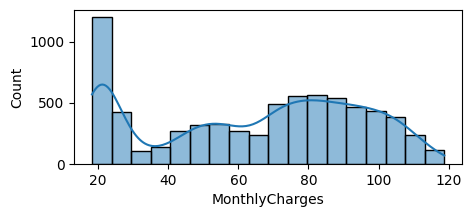

In [ ]:
# If numeric check the distribution
# histogram
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyCharges',kde=True)
plt.show()

In [ ]:
# Find skew
# skew = [-0.5,0.5]---> normal
# skew > 0.5 --> right skew
# skew <-0.5 --->left skew
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

Since skewness is within [-0.5,0.5] the distribution of MonthlyCharges is normal. We have to replace missing value with mean.

In [ ]:
# find mean
data.loc[:,'MonthlyCharges'].mean()

np.float64(64.74958102542253)

In [ ]:
# replace with mean
data.loc[:,'MonthlyCharges'] = data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].mean())

In [ ]:
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

**TotalCharges**

In [ ]:
# check the data type
data.loc[:,'TotalCharges'].dtypes

dtype('O')

Since data type of **Total charges** is object though it has a numeric values. We have to do typecasting to convert object to float64.

1. **astype** : Used to convert one data type into other if column has **no missing values**.
2. **pd.to_numeric** : Used to convert data type of column into other data type  when **there are missing values** in data

In [ ]:
# Type casting: converting one data type to other
data.loc[:,'Total_Charges'] = pd.to_numeric(data.loc[:,'TotalCharges'],errors='coerce')
# coerce : converts empty string to null/nan

In [ ]:
data.loc[:,'Total_Charges'].dtypes

dtype('float64')

In [ ]:
# drop the old column
data.drop(columns='TotalCharges',inplace=True)

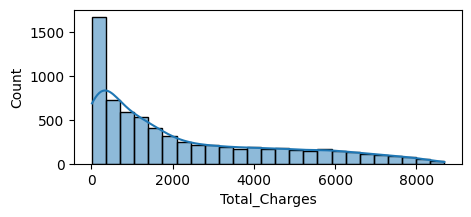

In [ ]:
# check distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='Total_Charges',kde=True)
plt.show()

In [ ]:
# find skew
data.loc[:,'Total_Charges'].skew()

np.float64(0.9616058347613503)

In [ ]:
# clearly skewness is greater than 0.5 , the distribution is right skewed
# find median
data.loc[:,'Total_Charges'].median()

1397.3

In [ ]:
# fill with median
data.loc[:,'Total_Charges']=data.loc[:,'Total_Charges'].fillna(data.loc[:,'Total_Charges'].median())

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# break till 10.30am